# ETFs: letting the features set the exposures

[`11a_pca`](11a_pca.ipynb) gave each fund one loading per factor, fitted once on the training
window's return matrix, and never looked at a feature. That is a strong assumption about these
hundred funds: whatever a fund's momentum, volatility or yield-curve exposure was doing, its
share of each common movement was a constant for the whole training window.

**Instrumented PCA keeps the factor structure and drops that constant.** A fund's exposure on a
given date is a linear function of its own feature row on that date - one map, shared by every
fund and every date, from features to exposures - and the factor returns are then whatever best
explains that date's cross-section given those exposures. The two are fitted together, by
alternating between them until neither moves.

What that buys is a constraint rather than more capacity. [`06_linear`](06_linear.ipynb) had one
free coefficient per feature and one cross-section at a time to find them in. IPCA has one map
from the features to `n_factors` exposures, estimated on every fund-date in the training window
at once. That is fewer free parameters against more data, and it is the whole argument for the
family. It is also its limitation: if the relationship between a feature and the exposure it
implies is not linear, the constraint is wrong rather than merely tight, which is what
[`11c_conditional_autoencoder`](11c_conditional_autoencoder.ipynb) relaxes.

**The estimator can fail to fit, and this notebook refuses to publish when it does.** Alternating
least squares is not guaranteed to converge, and it does not when the cross-section is too narrow
to identify the number of factors asked for - a hundred funds against five factors is
comfortable; a handful of funds against five is not. `_require_ipca_convergence` in
[`case_studies/utils/latent_factors/cv.py`](../utils/latent_factors/cv.py) raises rather than
registering predictions from a fit that never settled, so an unconverged run is a failure here
and not a quiet row in the population.

**Learning objectives.** By the end of this notebook you will be able to:

- Say what changes between a factor model with fixed exposures and one whose exposures are a
  function of observable features, and what each buys.
- Read an alternating-least-squares configuration - iteration cap, tolerance, two ridge
  penalties - and say what each controls.
- Explain why a fit that has not converged must not be published, and where that is enforced.
- Read a population published for every declared label rather than only the traded one.

**Book reference**: Chapter 14, Section 14.5 (Bridging economics and statistics with advanced
models). Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run log this
notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) for the feature matrix this one reads,
[`05_evaluation`](05_evaluation.ipynb) for the walk-forward folds, and
[`11a_pca`](11a_pca.ipynb), which is the same factor structure with the conditioning removed.

**What it writes**: one training run per label and one complete validation prediction set per
label, in `run_log/registry.db` and under `run_log/training/` and `run_log/predictions/`, grouped
under a population named for this model. The family splits across five notebooks, so each
publishes its own population rather than one shared one.
[`13_model_analysis`](13_model_analysis.ipynb) compares them against the other families and
[`14_backtest`](14_backtest.ipynb) backtests every member and selects on validation backtest
Sharpe. **Selection happens there, not here.**

In [1]:
"""Fit the declared ETF instrumented-PCA population on the walk-forward folds."""

import json

import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    primary_label,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""

MODEL_NAME = "ipca"

In [4]:
study = open_study("etfs", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 1. Which labels, and what the configuration says

Every label whose training menu declares `latent_factors:` is fitted, and both do: `fwd_ret_21d`,
the total return over the 21 trading days after the decision date, and `fwd_ret_5d`, the same
thing over five. Unlike [`11a_pca`](11a_pca.ipynb), the label is part of what is being estimated
here - the factor returns are the ones that best explain the cross-section of *that* forward
return - so the two rows below are two different fits and not one fit scored twice. `LABELS`
restricts the run to a subset when you want one.

In [5]:
declared_labels(study, "latent_factors")

('fwd_ret_21d', 'fwd_ret_5d')

The configuration comes from two files, and they say different kinds of thing.
`case_studies/config/ipca/ipca.yaml` declares `n_factors`, how many common factors to extract,
and `checkpoint_interval: 0`, which says there is no intermediate training state to publish:
alternating least squares runs to convergence rather than for a number of epochs, so a fold
produces one fitted map and one set of predictions. There is no point at which a reader could
have stopped it, and publishing a checkpoint schedule would invent a choice the estimator does
not offer.

`config/setup.yaml` declares the solver itself under `modeling.latent_factors.model_kwargs.ipca`:
`max_iter`, the cap on alternations; `tol`, how small a step counts as settled; and
`factor_ridge` and `gamma_ridge`, penalties on the two least-squares steps. Those four are inside
the training identity rather than recorded beside it, because a fit stopped at a different
tolerance is a different fitted model.

In [6]:
configs = load_model_configs(
    study,
    "latent_factors",
    labels=LABELS or None,
    config_names=[MODEL_NAME],
)
configs.select("label", "config_name", "params")

label,config_name,params
str,str,str
"""fwd_ret_21d""","""ipca""","""n_factors=5"""
"""fwd_ret_5d""","""ipca""","""n_factors=5"""


`LABELS` narrows what is fitted, and a narrowed run declares a different set of members than the
canonical population does. A population is immutable once written, so such a run must publish
under its own name: on a fresh workspace it would otherwise register an incomplete snapshot under
the canonical one, and where the full population already exists the registry refuses it.

The comparison is against this model's own declared rows rather than the whole `latent_factors`
catalog. The family is split across five notebooks and each publishes one model, so the complete
catalog is five times what this one publishes, and comparing against it would report every
canonical run as narrowed.

In [7]:
declared = load_model_configs(study, "latent_factors", config_names=[MODEL_NAME])
if set(configs.get_column("label")) != set(declared.get_column("label")) and not POPULATION_NAME:
    raise ValueError(
        f"this run fits {configs.height} of the {declared.height} declared labels, so it cannot "
        "publish the canonical population; pass POPULATION_NAME to give it its own"
    )

### Where this one runs

`config/setup.yaml` puts no device on the latent-factor family, which leaves it to whatever the
machine offers - and a fit that lands on a GPU on one machine and a CPU on another is not the
same computation, because the device is inside the hashed identity rather than recorded beside
it. IPCA is alternating least squares over the panel and has no GPU implementation, so this
notebook declares CPU explicitly, and a bounded number of fold workers with it: the folds are
independent fits and this is the one member of the family the runner allows to run them in
parallel.

In [8]:
overrides = {"device": "cpu", "fold_workers": 4}
overrides

{'device': 'cpu', 'fold_workers': 4}

## 2. Binding the declarations to the data

A menu entry says which estimator to fit. It does not say which fund-date pairs have both a
feature row and a label, or where the walk-forward folds fall. **Resolving** a request goes and
finds that: it reads the label and feature files, computes the fold boundaries from the
walk-forward parameters in `config/setup.yaml`, and works out the exact set of rows each fit is
expected to predict. It fits nothing, so the plan can be read before any training starts.

Four things to check in it:

- **`feature_count` is the width of the map being estimated.** It is the number of columns that
  get turned into exposures, and unlike [`11a_pca`](11a_pca.ipynb) this member reads every one of
  them. `eligible_entities` is the number of funds in the cross-section the factors are fitted
  on, and it has to be comfortably larger than `n_factors` for the fit to be identified at all.
- **`folds` is the same on both rows**, and equals the number of walk-forward splits
  [`05_evaluation`](05_evaluation.ipynb) established.
- **`validation_start` and `validation_end` bracket the development sample.** The held-out tail
  is scored once, at the end of the case study; any of it visible here would mean it had been
  used to choose something.
- **`checkpoints` is 1**, for the reason the configuration gives above.

Each row also carries a `training_hash`: the identity of that computation, derived from
everything that can change its result. [`RUN_LOG.md`](../RUN_LOG.md#identity) sets out what goes
into one and what follows from it.

In [9]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    overrides=overrides,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "label",
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,i64,i64,i64,i64,i64,datetime[μs],datetime[μs]
"""fwd_ret_21d""","""ipca""",71,99,188473,8,1,2015-12-28 00:00:00,2023-11-29 00:00:00
"""fwd_ret_5d""","""ipca""",71,99,190009,8,1,2015-12-28 00:00:00,2023-12-21 00:00:00


The plan is also where a short population is visible. A run that fitted fewer labels than the
menu declares would still print an IC table and still register its rows; what it would not do is
announce the gap.

In [10]:
planned_pairs = set(zip(plan["label"], plan["config_name"], strict=True))
requested_pairs = set(zip(configs["label"], configs["config_name"], strict=True))
if planned_pairs != requested_pairs:
    raise RuntimeError(
        "the plan does not match the loaded IPCA menu; "
        f"missing {sorted(requested_pairs - planned_pairs)}, "
        f"unexpected {sorted(planned_pairs - requested_pairs)}"
    )
print(f"{len(requested_pairs)} label-configuration pairs")

2 label-configuration pairs


## 3. Fitting the population

`run_model_population` runs every resolved request. For one request it walks the folds, and on
each one:

1. takes the fund-dates inside that fold's training window,
2. alternates between two least-squares problems until they stop moving: given the current map
   from features to exposures, solve for each date's factor returns; given those factor returns,
   solve for the map. Both steps are ridge-penalised at the strengths `config/setup.yaml`
   declares, and the alternation stops when the step falls below `tol` or the iteration cap is
   reached,
3. applies the fitted map to the validation dates' feature rows to get each fund's exposure
   there, and multiplies those exposures by the training-window average factor returns to get a
   predicted return.

Step 3 is what makes this a forecast rather than a decomposition: the map and the factor premia
come from the training window only, and the validation dates contribute nothing to either. It is
also where the difference from [`11a_pca`](11a_pca.ipynb) shows up in the output rather than in
the description - the exposures are read off feature rows that change from day to day, so the
prediction changes with them. Section 4 checks that against the published predictions.

**A fold that did not converge stops the run.** The runner records whether each fold's
alternation settled, and `_require_ipca_convergence` raises if any did not, before anything is
registered. That is the check that turns a too-narrow cross-section into a failure instead of a
population member fitted from wherever the iteration happened to stop.

**How narrow is too narrow is a question with a measured answer, and it is the reason a reduced
run of this notebook has to reduce the factor count as well as the universe.** A date's factor
returns are solved from that date's cross-section, so the number of funds priced on a date is a
hard ceiling on the number of factors: five funds cannot support five factors whatever the
tolerance says. The practical ceiling is lower than the arithmetic one. Measured on the
five-fund fixture the CI entry uses, at the `max_iter` declared above: five and three factors
spend every alternation without settling, two factors settle on one fold and not the other, and
one factor settles in under a second. `tests/overrides.yaml` carries the per-fold timings, which
are what distinguish the two explanations - a fold that fails takes the full iteration cap and a
fold that converges stops early, so the times read out the iterations. That is a system which is
identified or is not, rather than one that needed a larger budget.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, computed from the resolved specifications and written down before the first fit.
Afterwards every member must exist and be complete, which is what makes the downstream comparison
well defined - [`14_backtest`](14_backtest.ipynb) backtests this population, not whatever
predictions happen to be in the registry.

`SUPERSEDES_POPULATION` names the population hash this run replaces. A population is the set of
prediction identities, so anything that moves a training identity - a changed tolerance as much
as a changed label menu - produces a different set under the same name, and the registry refuses
to write it without being told which snapshot it supersedes. It is empty here because this
notebook, run as it stands, reproduces the members already published under that name rather than
changing them, and reproducing a published list is not a replacement. Fill it in when you have
changed something that moves an identity and want the new set to take the name; the error raised
on the attempt tells you which hash to name. A reduced-scale run passes it empty whatever the
default is: a population produced under a reduction is thrown away with the workspace it was
written to, so it has no lineage to extend.

In [11]:
population_name = POPULATION_NAME or f"etfs-{MODEL_NAME}-validation-v1"
execution, population = run_model_population(
    study,
    resolved,
    population_name=population_name,
    supersedes=SUPERSEDES_POPULATION or None,
)

published_sets = sum(len(run.predictions) for run in execution.runs)
print(f"{len(execution.runs)} configurations, {published_sets} prediction sets")
print(f"population {population.name}: {len(population.members)} members")

Latent factor CV: 1 models × 8 folds
Log file: ~/ml4t/artifacts/case_studies/etfs/run_log/training/d881b1dc9dbe/.models.820754a807b3471fafd0c34dc429d0d5.tmp/latent_factors.log
Scoring: dates=all cadence=- step=1 checkpoint_selection=fixed reporting_epoch=0
  ipca (K=5):


    Fold 0: ragged train=2484, val=231, max_N=96


    Fold 1: ragged train=2484, val=252, max_N=96


    Fold 2: ragged train=2484, val=252, max_N=96


    Fold 3: ragged train=2484, val=252, max_N=96


...

      fold 7: fit complete, iterations=31, converged=True, 13.9s
      fold 0: reported_epoch=0, IC=-0.0022, 21.0s
      fold 1: reported_epoch=0, IC=+0.0287, 33.1s
      fold 2: reported_epoch=0, IC=+0.0710, 26.7s


      fold 3: reported_epoch=0, IC=+0.0542, 21.7s
      fold 4: reported_epoch=0, IC=+0.1026, 17.5s
      fold 5: reported_epoch=0, IC=+0.0120, 15.0s
      fold 6: reported_epoch=0, IC=+0.0816, 15.5s


      fold 7: reported_epoch=0, IC=-0.0686, 13.9s
    -> best epoch=0, IC=+0.0349 (114.3s)


  Best: ipca (IC=+0.0349)


2 configurations, 2 prediction sets
population etfs-ipca-validation-v1: 2 members


A second run of this notebook fits nothing. Every identity is re-derived from the inputs, the
registry already holds the matching rows, and the runner returns the stored result rather than
fitting again - so re-running it unchanged costs the time it takes to read the data. The
latent-factor runner reports no per-fold fitted-or-reused breakdown, unlike the linear and
boosted families, so the counts above are of what the population holds rather than of what this
particular run computed.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("etfs", workspace="~/ml4t-experiments")
configs = load_model_configs(study, "latent_factors", labels=["fwd_ret_5d"], config_names=["ipca"])
requests = model_requests(study, configs, overrides={"device": "cpu", "fold_workers": 4})
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-ipca-v1")
```

To change the number of factors, edit `case_studies/config/ipca/ipca.yaml`; to change the solver,
edit `model_kwargs.ipca` in `config/setup.yaml`. Either changes this configuration's identity, so
its result registers as a new row beside the old one rather than replacing it. Give the run its
own `population_name`: a name refers to one set of members permanently, and reusing it for a
different set raises. [`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the
rest, including how to rehearse on a reduced universe first - and note that a reduced universe is
exactly the setting where this estimator stops being identified, so a rehearsal has to reduce the
factor count with it.

**Choosing that reduced factor count has an obvious wrong answer, and it is worth naming because
the reasoning for it sounds right.** The tempting choice is the largest count that can be made to
finish - keep it close to the production five, and raise `max_iter` until the folds stop
failing - because staying near the real configuration seems more faithful to it. What that
actually buys is a rehearsal sitting on the identification boundary, where whether a fold settles
depends on the order the floating-point operations happened to run in; the same fixture and the
same parameters then converge on one machine and not another.
`sp500_equity_option_analytics` runs its reduced IPCA at two factors and carries `reruns: 2`
alongside it, which is that instability being absorbed by a retry rather than diagnosed. Pick a
count below the boundary instead, and read where the boundary is off the per-fold iteration
counts rather than off whether the run went green.

## 4. What came out

One row per label, read back from the registry. `ic_mean` is the **information coefficient**: on
each validation date, rank the funds by the model's prediction, rank them by the return they went
on to earn, correlate the two rankings, and average that daily correlation over the validation
period. It measures whether the model orders the cross-section correctly, on a scale where zero
is no relationship.

`ic_n_days` is how many validation dates produced a defined correlation, and a row measured on
fewer of them is not comparable with one measured on all of them - which is why it is shown
beside the mean rather than left implicit. The two labels have different numbers of scoreable
dates before any model is fitted, because a 21-day forward return runs out of window earlier than
a five-day one does.

The published catalog is checked against the population planned before fitting rather than
against its own row count, because a run that lost a member would otherwise report a shorter
table and nothing else.

In [12]:
catalog = execution.catalog_rows.select(
    "label",
    "config_name",
    "complete",
    "checkpoint_kind",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort("label")

if set(catalog.get_column("prediction_hash")) != set(population.members):
    raise RuntimeError("the published catalog differs from the population planned before fitting")
if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("a partial IPCA prediction set cannot pass to backtesting")

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders by whichever
# label it did fit rather than by one that is not there.
ordered_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
print(f"{catalog.height} candidate models across {len(ordered_labels)} labels")
catalog.select("label", "checkpoint_value", "ic_mean", "ic_std", "ic_n_days", "n_folds")

2 candidate models across 2 labels


label,checkpoint_value,ic_mean,ic_std,ic_n_days,n_folds
str,i64,f64,f64,f64,f64
"""fwd_ret_21d""",0,0.041272,0.092609,1995.0,8.0
"""fwd_ret_5d""",0,0.034913,0.051349,2011.0,8.0


### What the headline number averages, and what the fit had to do to produce it

`ic_mean` is one number over the whole validation period, and the eight folds behind it are
fitted on different training windows and scored on different years. The table below recomputes
each fold's mean IC from the published predictions, which is where the dispersion behind a
single figure becomes visible.

Beside it, read back from the `fold_extras.json` the training run wrote, is how many alternations
each fold's fit took before the step fell below `tol`. That count is the only evidence that the
iteration cap in `config/setup.yaml` is a bound the estimator never meets rather than one it runs
into, and it comes from the stored artifact rather than from the runner's log so it is here
whether this execution fitted the folds or reused a fit already registered.

In [13]:
published = {result.hash: result for run in execution.runs for result in run.predictions}
training_by_label = {
    run.training.registry_record()["label"]: run.training for run in execution.runs
}


def _fold_ic(prediction_hash: str) -> pl.DataFrame:
    """Mean daily rank correlation of prediction against realised return, within each fold."""
    return (
        published[prediction_hash]
        .load()
        .group_by("fold", "timestamp")
        .agg(pl.corr("prediction", "actual", method="spearman").alias("ic"))
        .group_by("fold")
        .agg(pl.col("ic").mean().alias("fold_ic"))
        .sort("fold")
    )


def _fold_solver(label: str) -> pl.DataFrame:
    training = training_by_label[label]
    extras_path = training.root / "run_log" / "training" / training.hash / "fold_extras.json"
    return pl.DataFrame(
        [
            {
                "fold": int(extra["fold_id"]),
                "iterations": int(extra["iterations"]),
                "iteration_cap": int(extra["max_iter"]),
                "converged": bool(extra["converged"]),
            }
            for extra in json.loads(extras_path.read_text())
        ]
    ).sort("fold")


by_fold = {
    row["label"]: _fold_ic(row["prediction_hash"]).join(_fold_solver(row["label"]), on="fold")
    for row in catalog.iter_rows(named=True)
}
for label in ordered_labels:
    folds = by_fold[label]
    ic = folds.get_column("fold_ic")
    iterations = folds.get_column("iterations")
    print(
        f"{label}: mean {ic.mean():+.4f}, standard deviation across folds {ic.std():.4f}, "
        f"{(ic < 0).sum()} of {folds.height} folds negative; "
        f"{iterations.min()}-{iterations.max()} alternations against a cap of "
        f"{folds.get_column('iteration_cap').max()}"
    )

by_fold[ordered_labels[0]]

fwd_ret_21d: mean +0.0413, standard deviation across folds 0.0990, 3 of 8 folds negative; 53-110 alternations against a cap of 1000
fwd_ret_5d: mean +0.0349, standard deviation across folds 0.0549, 2 of 8 folds negative; 28-61 alternations against a cap of 1000


fold,fold_ic,iterations,iteration_cap,converged
i64,f64,i64,i64,bool
0,-0.008355,85,1000,true
1,-0.018373,97,1000,true
2,0.118413,110,1000,true
3,0.051903,107,1000,true
4,0.150416,69,1000,true
5,0.012963,59,1000,true
6,0.156608,53,1000,true
7,-0.133401,77,1000,true


### The prediction moves within a fold, and that is the whole difference

[`11a_pca`](11a_pca.ipynb) checked that each fund carried exactly one predicted value for the
whole of a fold's validation window, because its loadings and factor premia were both fitted once
and neither depended on the date. Here the premia are still fitted once per fold, but the
exposures are read off feature rows that change daily, so the same check must come out the other
way. The cell below counts the distinct predicted values each fund holds within each fold and
raises if any fund holds only one: a constant would mean the feature rows were not reaching the
exposures, which is the failure this conditioning exists to avoid and which no IC number would
reveal.

In [14]:
# The label whose predictions the rest of this section reads, named rather than taken by position:
# `execution.runs` is ordered by how the requests were submitted, not by which label leads.
charted_label = ordered_labels[0]
charted_hash = catalog.filter(pl.col("label") == charted_label).get_column("prediction_hash")[0]
charted = published[charted_hash]
predictions = pl.read_parquet(
    charted.root / "run_log" / "predictions" / charted.hash / "predictions.parquet"
)
per_fund_values = predictions.group_by("fold", "symbol").agg(
    pl.col("prediction").n_unique().alias("distinct_predictions"),
    pl.len().alias("dates"),
)
frozen = per_fund_values.filter((pl.col("distinct_predictions") == 1) & (pl.col("dates") > 1))
if frozen.height:
    raise RuntimeError(
        f"{frozen.height} fund-fold pairs carry a single predicted value across several dates; "
        "the exposures are not moving with the features"
    )
print(
    f"{per_fund_values.height} fund-fold pairs over "
    f"{predictions.n_unique('timestamp')} validation dates"
)

764 fund-fold pairs over 1995 validation dates


### How fast the ranking turns over

Because the exposures move, the ordering of the funds moves with them, and how fast it does is a
property of the fitted model worth reading on its own. The measure is the rank correlation
between each validation date's predicted cross-section and the one that preceded it, averaged
within a fold: near one means the conditioning is barely changing the ordering from day to day
and the model is close to the static ranking [`11a_pca`](11a_pca.ipynb) publishes; well below one
means the features are moving funds past each other, which a strategy trading this signal pays
for in turnover.

It says nothing about accuracy. A ranking that turns over quickly is not better or worse than one
that does not; it is a different thing to hold, and [`17_costs`](17_costs.ipynb) is where the
holding cost is priced.

In [15]:
ranked = predictions.with_columns(rank=pl.col("prediction").rank().over("timestamp"))
dates = ranked.select("fold", "timestamp").unique().sort("timestamp")
pairs = dates.with_columns(previous=pl.col("timestamp").shift(1).over("fold")).drop_nulls(
    "previous"
)
today = ranked.select("timestamp", "symbol", today_rank="rank")
yesterday = ranked.select(previous="timestamp", symbol="symbol", previous_rank="rank")
daily = (
    pairs.join(today, on="timestamp", how="inner")
    .join(yesterday, on=["previous", "symbol"], how="inner")
    .group_by("fold", "timestamp")
    .agg(pl.corr("today_rank", "previous_rank").alias("rank_correlation"))
)
persistence = (
    daily.group_by("fold")
    .agg(
        pl.col("rank_correlation").mean().alias("mean_day_over_day_rank_correlation"),
        pl.len().alias("date_pairs"),
    )
    .sort("fold")
)
persistence

fold,mean_day_over_day_rank_correlation,date_pairs
i64,f64,u32
0,0.956222,230
1,0.970323,251
2,0.968254,251
3,0.922625,251
4,0.944896,251
5,0.943874,251
6,0.976802,251
7,0.962947,251


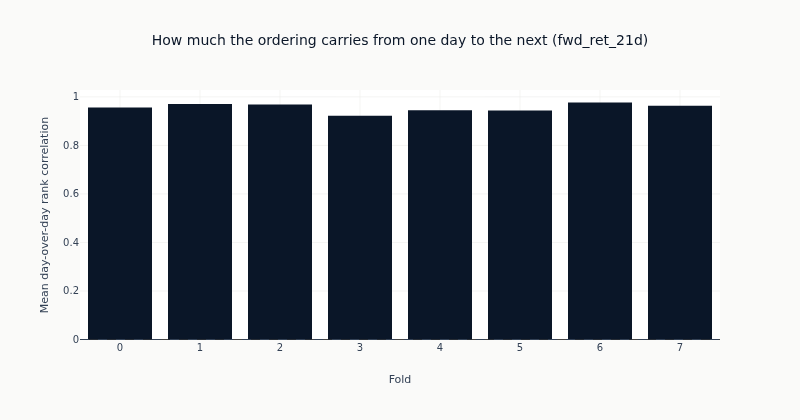

In [16]:
fig = go.Figure(
    go.Bar(
        x=[str(fold) for fold in persistence.get_column("fold").to_list()],
        y=persistence.get_column("mean_day_over_day_rank_correlation").to_list(),
        marker_color=COLORS["blue"],
        showlegend=False,
    )
)
fig.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.update_yaxes(title_text="Mean day-over-day rank correlation")
fig.update_xaxes(title_text="Fold")
fig.update_layout(
    title=f"How much the ordering carries from one day to the next ({charted_label})",
    height=420,
    width=800,
    margin=dict(t=90),
)
# The range is read off the frame rather than asserted, so the alt text stays true of the next run.
_values = persistence.get_column("mean_day_over_day_rank_correlation")
show_plotly_with_alt(
    fig,
    "Bar chart of the mean day-over-day rank correlation of the predicted cross-section, one bar "
    "per walk-forward fold, with a dashed zero line. Counted from the frame: "
    f"{persistence.height} folds, values from {_values.min():.2f} to {_values.max():.2f}.",
)

## 5. What to notice

**Letting the features set the exposures moves the average off zero, and not past the spread it
would have to clear.** The mean validation IC is **+0.041** on the primary label and **+0.035**
on the five-day variant, against **-0.033** and **+0.010** for the unconditioned decomposition in
[`11a_pca`](11a_pca.ipynb). Behind the primary number the eight fold ICs run -0.008, -0.018,
+0.118, +0.052, +0.150, +0.013, +0.157 and -0.133: three of the eight are negative, and their
standard deviation across folds is 0.099, about two and a half times the mean they average to.
Conditioning is worth something on both labels. It is not worth enough to make any one fold's
ordering dependable.

**The ordering moves every day, and by very little.** The check above found no fund holding a
single predicted value through a fold, so the exposures are tracking the feature rows as
intended. The day-over-day rank correlation says how far that gets: between **0.92 and 0.98** on
every one of the eight folds. Two things follow, and they point in opposite directions for a
reader deciding what to do with this model. A strategy trading it turns over slowly, which
[`17_costs`](17_costs.ipynb) will price as an advantage. And the 1,995 daily correlations behind
`ic_mean` are nowhere near 1,995 independent readings, because consecutive dates are scoring
almost the same ordering against a different day of returns, so `ic_std / sqrt(ic_n_days)`
understates the uncertainty on `ic_mean` here much as it did for the forecast that was frozen
within a fold. It understates it by less; it does not stop understating it.

**The iteration counts are a result, and this case study had never read them.** The primary
label's eight folds settle at 85, 97, 110, 107, 69, 59, 53 and 77 alternations against
`tol = 1e-05`; the five-day label settles between 28 and 61. `config/setup.yaml` declared a cap
of 100 alternations, which sits inside the primary label's own distribution and above all of the
five-day label's - two folds of one label needed more than the budget while the other label never
came close to it. The cap is now 1000, set off these counts. No prediction was ever published
from a truncated fit: `_require_ipca_convergence` refuses the whole run when any fold stops at
the cap, which is why the wrong number surfaced as a failure rather than as eight plausible
ICs. What made it survive being wrong is that nothing had fitted this estimator at production
width in this case study before, so the declared cap had never been asked to hold.

**What this establishes for the rest of the family.** PCA and IPCA differ in one thing: whether
a fund's exposure is a fixed number or a function of that fund's 71 feature values on the day.
Both fit the same panel over the same folds, both average their factor returns over the same
training windows, and both publish one checkpoint. The gap between -0.033 and +0.041 on the
primary label is what that one difference is worth with a **linear** map from features to
exposures. [`11c_conditional_autoencoder`](11c_conditional_autoencoder.ipynb) keeps the two-stage
structure and replaces that map with a network, so the comparison that follows isolates the map
rather than the idea of conditioning.

**Known limitations.** `n_factors` is declared at five rather than chosen, and nothing here tests
whether a different count orders the cross-section better - that would be a search over
validation IC, which this notebook is arranged to avoid. Five factors against roughly 96 funds is
a comfortable ratio but not a large one, and the panel narrows as the folds roll forward: the
last fold prices 90 funds where the first prices 96, so the eight fold ICs are not eight readings
of one experiment. The ridge strengths are declared too, and a ridge that binds changes what
converges. And every number here is measured on validation folds that have been read many times
over by the time a case study reaches this notebook.

**Next**: [`11c_conditional_autoencoder`](11c_conditional_autoencoder.ipynb) keeps this exact
structure - features to exposures, exposures times factor returns - and replaces the linear map
with a network, so the difference between the two is the shape of one function and nothing else.